In [ ]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
import pandas as pd
import torch
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from IPython.display import clear_output
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
!wget -O ./data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-12-03 18:11:06--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘./data.txt.zip’

./data.txt.zip          [             <=>    ] 201.24M  72.6MB/s    in 2.8s    

2025-12-03 18:11:09 (72.6 MB/s) - ‘./data.txt.zip’ saved [211011981]



Тут код чтобы выбрать устройство на котором будут вычисления. Я использую T4 в Colab, но чтобы код был воспроизводим сделаю выбор того, что доступно в конкретный момент

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется {device}")

Используется cuda


In [ ]:
df = pd.read_csv('data.txt.zip', header=None)

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

Посмотрим на распределение целевой переменной

Среднее: 1998.40
Медиана: 2002.0
Максимум: 2011
Минимум: 1922
Стандартное отклонение: 10.93


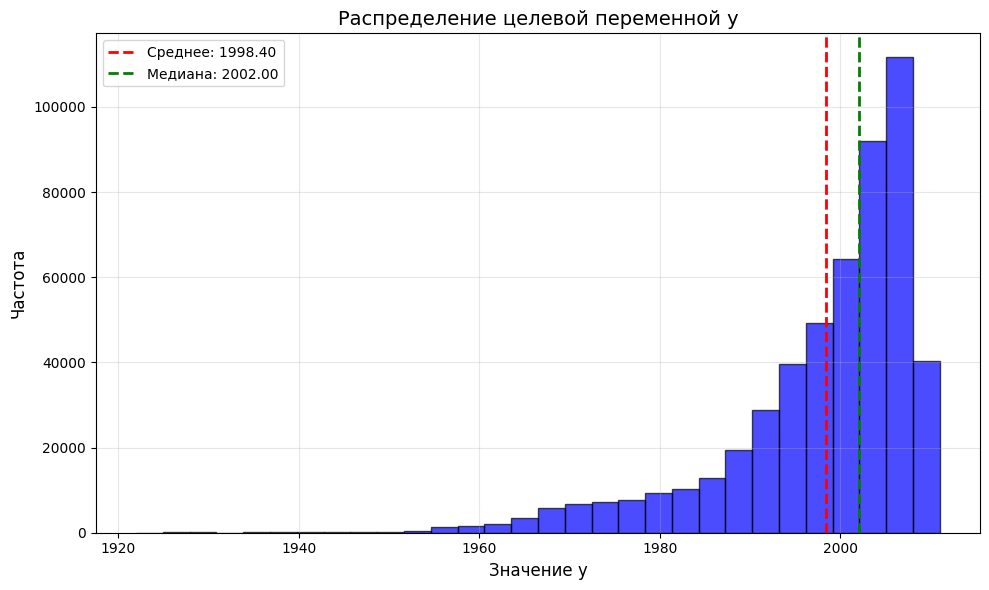

In [ ]:
print(f"Среднее: {np.mean(y):.2f}")
print(f"Медиана: {np.median(y)}")
print(f"Максимум: {np.max(y)}")
print(f"Минимум: {np.min(y)}")
print(f"Стандартное отклонение: {np.std(y):.2f}")

plt.figure(figsize=(10, 6))
plt.hist(y, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.mean(y), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(y):.2f}')
plt.axvline(np.median(y), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(y):.2f}')
plt.title('Распределение целевой переменной y', fontsize=14)
plt.xlabel('Значение y', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Целевая переменная распределена со скосом вправо, поэтому могут быть проблемы с обучением на годах 1922 – 1980 (тк там мало данных). Но скорее всего это решаемо. В целом данных почти везде хватает, сильных пробелов нет

Разделим на тренировочную и тестовую выборку. Я тестировал разные варианты, но с учетом всего, что будет снизу – лучший вариант 0,2 тест 0,8 обучение

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)
X_train.shape

(412276, 90)

Видим что у нас 90 признаков, но не факт что все из них нам нужны, к тому же чем больше признаков, тем дольше обучается модель. Поэтому я пробовал отобрать те, которые более всего по модулю коррелируют с целевой переменной. По сравнению с ситуацией без отбора признаков – отбор значительно ускоряет процесс обучения, при этом немного повышает ошибку. Поэтому я отбирал лучшие признаки и тестировал разные настройки модели, а когда остальные настройки подобраны – брал все признаки и получал максимальную точность

In [ ]:
selected_indices = []
print("Признаки с |corr| > 0.000001 (просто чтобы взять всё конкретно сейчас):")
for i in range(X_train.shape[1]):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    if abs(corr) > 0.000001:
        selected_indices.append(i)
        print(f"  Признак {i}: {corr:+.3f}")
X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]
print(f"\nОтобрано {len(selected_indices)} из {X_train.shape[1]} признаков")


Признаки с |corr| > 0.000001 (просто чтобы взять всё конкретно сейчас):
  Признак 0: +0.225
  Признак 1: +0.022
  Признак 2: -0.138
  Признак 3: -0.003
  Признак 4: +0.019
  Признак 5: -0.187
  Признак 6: +0.110
  Признак 7: -0.035
  Признак 8: -0.025
  Признак 9: +0.033
  Признак 10: +0.031
  Признак 11: -0.097
  Признак 12: +0.024
  Признак 13: +0.078
  Признак 14: -0.007
  Признак 15: +0.032
  Признак 16: +0.030
  Признак 17: +0.021
  Признак 18: -0.005
  Признак 19: +0.087
  Признак 20: -0.056
  Признак 21: +0.049
  Признак 22: +0.046
  Признак 23: -0.060
  Признак 24: +0.065
  Признак 25: -0.019
  Признак 26: -0.022
  Признак 27: +0.010
  Признак 28: +0.074
  Признак 29: +0.017
  Признак 30: -0.073
  Признак 31: +0.027
  Признак 32: -0.090
  Признак 33: +0.042
  Признак 34: -0.044
  Признак 35: -0.101
  Признак 36: -0.042
  Признак 37: +0.075
  Признак 38: +0.071
  Признак 39: -0.123
  Признак 40: -0.061
  Признак 41: +0.013
  Признак 42: -0.000
  Признак 43: +0.014
  Признак 44: 

Теперь отскалируем признаки к стандартному нормальному распределению с помощью готового модуля из sklearn

In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_selected)
X_test_scaled = scaler_X.transform(X_test_selected)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

Превратим массивы в тензоры и отправим на CPU/GPU, а также сразу запишем input size чтобы впоследствии использовать его

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)
input_size = X_train_scaled.shape[1]
input_size

90

Я взял 7 слоев которые начинаются со 180 нейронов (изначально 90 признаков), затем постепенно уменьшаются в 2 раза, тк эта связка давала наиболее стабильное обучение (ошибка уменьшалась без рывков и давала низкую ошибку),  BatchNorm (нормализацию данных) добавил тк он еще сильнее уменьшил ошибку и сгладил график ошибок. Dropout добаил тк сеть глубокая и склонна к переобучению. Еще я пробовал добавлять остаточные связи, но они на 2-3 эпохе достигали какой-то одной ошибки (например 11.5) и с 3-10 эпоху она вообще не уменьшалась, поэтому решил не использовать. Попробовал разные функции активации, и tanh давал наименьшую ошибку в сравнении с relu, leaky relu и sigmoid (для tanh я впоследствии сделал стартовые веса Xavier, чтобы улучшить связку)

In [ ]:
class LinearRegression(torch.nn.Module):
    def __init__(self, input_size):
        super(LinearRegression, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, 180)
        self.bn1 = torch.nn.BatchNorm1d(180)
        self.layer2 = torch.nn.Linear(180, 90)
        self.bn2 = torch.nn.BatchNorm1d(90)
        self.layer3 = torch.nn.Linear(90, 45)
        self.bn3 = torch.nn.BatchNorm1d(45)
        self.layer4 = torch.nn.Linear(45, 24)
        self.bn4 = torch.nn.BatchNorm1d(24)
        self.layer5 = torch.nn.Linear(24, 12)
        self.bn5 = torch.nn.BatchNorm1d(12)
        self.layer6 = torch.nn.Linear(12, 6)
        self.bn6 = torch.nn.BatchNorm1d(6)
        self.layer7 = torch.nn.Linear(6, 1)
        self.dropout = torch.nn.Dropout(0.1)

    def forward(self, x):
        x = torch.tanh(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        x = torch.tanh(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        x = torch.tanh(self.bn3(self.layer3(x)))
        x = self.dropout(x)
        x = torch.tanh(self.bn4(self.layer4(x)))
        x = self.dropout(x)
        x = torch.tanh(self.bn5(self.layer5(x)))
        x = self.dropout(x)
        x = torch.tanh(self.bn6(self.layer6(x)))
        x = self.dropout(x)
        x = self.layer7(x)
        return x.squeeze()

Создаем собственно модель

In [ ]:
model = LinearRegression(input_size).to(device)

Я пробовал запустить обычную модель, она даже дает ошибку меньше 12, но можно было это улучшить, прописав стартовые веса. Тут я загуглил что для tanh функций хорошо работает Xavier_uniform. Он сглаживает изменения весов и делает обучение стабильнее. Также для ReLU/LeakyReLU пробовал Kaiming initialization, но их связка показывала более плохие результаты

In [ ]:
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        torch.nn.init.zeros_(m.bias)
model.apply(init_weights)

LinearRegression(
  (layer1): Linear(in_features=90, out_features=180, bias=True)
  (bn1): BatchNorm1d(180, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=180, out_features=90, bias=True)
  (bn2): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=90, out_features=45, bias=True)
  (bn3): BatchNorm1d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer4): Linear(in_features=45, out_features=24, bias=True)
  (bn4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer5): Linear(in_features=24, out_features=12, bias=True)
  (bn5): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer6): Linear(in_features=12, out_features=6, bias=True)
  (bn6): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer7): Linear(in_features=6, out_features=1, bias=True)
  (dropo

Делаем списки для отслеживания ошибок, чтобы потом выводить на графики

In [ ]:
train_rmses = []
test_rmses = []
train_maes = []
test_maes = []

Разделим данные на батчи, размер батча был выбран 2048, тк он улучшал показатели и при этом не сильно замедлял процесс обучения

In [ ]:
batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Цикл обучения с отслеживанием прогресса. MAE и RMSE отображаются на графиках после каждой эпохи (в исходном масштабе). Ставим 10 эпох, а также плавающий LR. Когда я делал высокий показатель LR (>0.1), то ошибка прыгала вверх-вниз (особенно на последних эпохах), а когда он был слишком маленьким – ошибка была довольно высокая. Поэтому я выбрал компромиссный вариант

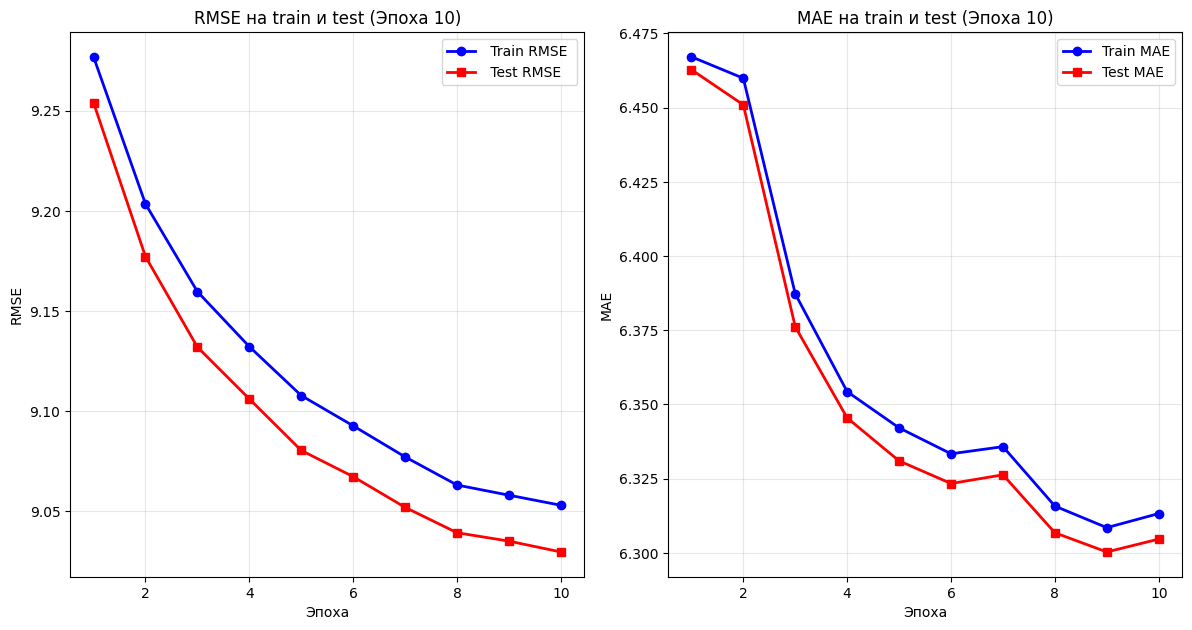

Обучение модели:  90%|######### | 9/10 [00:49<00:05,  5.05s/epoch, Train RMSE=9.05, Test RMSE=9.03]

In [ ]:
num_epochs = 10
def get_learning_rate(epoch, initial_lr=0.1):
    if epoch < 2:
        return initial_lr
    elif epoch < 5:
        return initial_lr * 0.75
    elif epoch < 8:
        return initial_lr * 0.5
    else:
        return initial_lr * 0.25

epoch_pbar = tqdm(range(num_epochs), desc="Обучение модели", unit="epoch")
for epoch in epoch_pbar:
    current_lr = get_learning_rate(epoch)
    model.train()
    for batch_X, batch_y in train_loader:
        # в цикле применяем модель к конкретному батчу
        batch_pred_scaled = model(batch_X)
        # вычисляем loss на батче
        batch_loss = torch.mean((batch_pred_scaled - batch_y) ** 2)
        # backward pass
        batch_loss.backward()
        # градиентный спуск
        with torch.no_grad():
            for param in model.parameters():
                if param.grad is not None:
                    param.data -= current_lr * param.grad.data
        model.zero_grad()

    model.eval()
    with torch.no_grad(): #отключает отслеживание операций для экономии памяти

        # перевод результатов модели на train выборке в массив numpy в оригинальной размерности
        train_pred_scaled = model(X_train_tensor)
        train_pred_cpu = train_pred_scaled.cpu().numpy()
        train_pred_original = scaler_y.inverse_transform(train_pred_cpu.reshape(-1, 1)).flatten()
        # подсчет train ошибок в оригинальной размерности
        train_rmse = np.sqrt(np.mean((train_pred_original - y_train) ** 2))
        train_mae = np.mean(np.abs(train_pred_original - y_train))
        # перевод результатов модели на test выборке в массив numpy в оригинальной размерности
        test_pred_scaled = model(X_test_tensor)
        test_pred_cpu = test_pred_scaled.cpu().numpy()
        test_pred_original = scaler_y.inverse_transform(test_pred_cpu.reshape(-1, 1)).flatten()
        # подсчет test ошибок в оригинальной размерности
        test_rmse = np.sqrt(np.mean((test_pred_original - y_test) ** 2))
        test_mae = np.mean(np.abs(test_pred_original - y_test))

    train_rmses.append(train_rmse)
    test_rmses.append(test_rmse)
    train_maes.append(train_mae)
    test_maes.append(test_mae)

    epoch_pbar.set_postfix({'Train RMSE': f'{train_rmse:.2f}', 'Test RMSE': f'{test_rmse:.2f}'})

# Графики

    clear_output(wait=True)
    plt.figure(figsize=(18, 12))
    # График RMSE
    plt.subplot(2, 3, 1)
    plt.plot(range(1, len(train_rmses) + 1), train_rmses, 'b-', marker='o', linewidth=2, label=' Train RMSE ')
    plt.plot(range(1, len(test_rmses) + 1), test_rmses, 'r-', marker='s', linewidth=2, label=' Test RMSE ')
    plt.xlabel('Эпоха')
    plt.ylabel('RMSE')
    plt.title(f'RMSE на train и test (Эпоха {epoch + 1})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    # График MAE
    plt.subplot(2, 3, 2)
    plt.plot(range(1, len(train_maes) + 1), train_maes, 'b-', marker='o', linewidth=2, label='Train MAE')
    plt.plot(range(1, len(test_maes) + 1), test_maes, 'r-', marker='s', linewidth=2, label='Test MAE')
    plt.xlabel('Эпоха')
    plt.ylabel('MAE')
    plt.title(f'MAE на train и test (Эпоха {epoch + 1})')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()
    display(epoch_pbar.container)

Итого за 10 эпох получается Test RMSE = 9.05, что в целом приемлемо. Можно еще улучшить модель за счет увеличения количества эпох, но и такой результат довольно хорош. MSE я считал для того чтобы в целом понимать как сильно мы отклоняемся от таргета в абсолютном значении. Значение 6.3 говорит что в датасете где года распределены от 1922 до 2011 модель в среднем ошибается на 6 лет, что звучит неплохо. Также можно видеть что на некоторых эпохах MAE увеличивается, а RMSE падает, я полагаю, что на конкретной эпохе модель начинает делать больше ошибок, но они становятся меньше в абсолютном значении (а значит квадрат ошибки становится сильно меньше), из-за чего RMSE (который сильнее "штрафует" за сильные отклонения чем MSE) – снижается